# Pergunta 9 - Modelo Preditivo de Risco de Defasagem

Objetivo:

Construir um modelo capaz de prever o risco futuro de defasagem dos estudantes a partir dos indicadores educacionais disponíveis.

Abordagem:

Utilizar os indicadores do ano atual para prever a ocorrência de defasagem no ano seguinte.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [ ]:
arquivo = list(uploaded.keys())[0]

df2022 = pd.read_excel(arquivo, sheet_name='PEDE2022')
df2023 = pd.read_excel(arquivo, sheet_name='PEDE2023')
df2024 = pd.read_excel(arquivo, sheet_name='PEDE2024')

print("Bases carregadas com sucesso!")

Bases carregadas com sucesso!


# Feature Engineering

## Estratégia de Modelagem

O objetivo do modelo é prever a ocorrência de risco de defasagem no ano seguinte.

Para isso, foram utilizadas informações do ano atual para prever a situação futura dos estudantes.

As seguintes etapas foram realizadas:

1. Integração longitudinal das bases de 2022→2023 e 2023→2024.
2. Criação da variável alvo RISCO_FUTURO.
3. Seleção das variáveis explicativas.
4. Tratamento de inconsistências e valores ausentes.
5. Construção do dataset final para modelagem.

## Variável Alvo

RISCO_FUTURO

- 0 = estudante sem risco de defasagem no ano seguinte
- 1 = estudante com risco de defasagem no ano seguinte


In [ ]:
base_22_23['RISCO_FUTURO'] = np.where(
    base_22_23['Defasagem'] < 0,
    1,
    0
)

base_23_24['RISCO_FUTURO'] = np.where(
    base_23_24['Defasagem_ANO_SEGUINTE'] < 0,
    1,
    0
)

In [ ]:
print("2022 -> 2023")
print(base_22_23['RISCO_FUTURO'].value_counts())

print("\n")

print("2023 -> 2024")
print(base_23_24['RISCO_FUTURO'].value_counts())

2022 -> 2023
RISCO_FUTURO
1    366
0    234
Name: count, dtype: int64


2023 -> 2024
RISCO_FUTURO
0    457
1    308
Name: count, dtype: int64


In [ ]:
features_22 = base_22_23[
    [
        'RA',
        'IAA',
        'IEG',
        'IPS',
        'IDA',
        'IPV',
        'IAN',
        'Ano ingresso',
        'Idade 22',
        'RISCO_FUTURO'
    ]
].copy()

In [ ]:
features_23 = base_23_24[
    [
        'RA',
        'IAA',
        'IEG',
        'IPS',
        'IPP',
        'IDA',
        'IPV',
        'IAN',
        'Ano ingresso',
        'Idade',
        'RISCO_FUTURO'
    ]
].copy()

features_23 = features_23.rename(
    columns={
        'Idade': 'Idade 22'
    }
)

In [ ]:
features_22['IPP'] = np.nan

In [ ]:
features_22 = features_22[
    [
        'RA',
        'IAA',
        'IEG',
        'IPS',
        'IPP',
        'IDA',
        'IPV',
        'IAN',
        'Ano ingresso',
        'Idade 22',
        'RISCO_FUTURO'
    ]
]

In [ ]:
dataset_ml = pd.concat(
    [features_22, features_23],
    ignore_index=True
)

In [ ]:
dataset_ml.shape

(1365, 11)

In [ ]:
dataset_ml.head()

,RA,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Ano ingresso,Idade 22,RISCO_FUTURO
0,RA-1,8.3,4.1,5.6,NaN,4.0,7.278,5.0,2016,19,0
1,RA-2,8.8,5.2,6.3,NaN,6.8,6.778,10.0,2017,17,0
2,RA-5,7.9,8.6,5.6,NaN,5.2,7.389,10.0,2016,17,0
3,RA-6,7.9,4.5,7.5,NaN,3.3,7.222,5.0,2021,18,0
4,RA-7,0.0,8.4,7.5,NaN,7.6,7.667,5.0,2017,18,0


In [ ]:
dataset_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RA            1365 non-null   object 
 1   IAA           1306 non-null   float64
 2   IEG           1293 non-null   float64
 3   IPS           1303 non-null   float64
 4   IPP           693 non-null    float64
 5   IDA           1293 non-null   float64
 6   IPV           1293 non-null   float64
 7   IAN           1365 non-null   float64
 8   Ano ingresso  1365 non-null   int64  
 9   Idade 22      1365 non-null   object 
 10  RISCO_FUTURO  1365 non-null   int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 117.4+ KB


In [ ]:
dataset_ml.isnull().sum()

,0
RA,0
IAA,59
IEG,72
IPS,62
IPP,672
IDA,72
IPV,72
IAN,0
Ano ingresso,0
Idade 22,0


In [ ]:
dataset_ml['RISCO_FUTURO'].value_counts(normalize=True) * 100

,proportion
RISCO_FUTURO,
0,50.622711
1,49.377289


In [ ]:
dataset_ml.describe()

,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Ano ingresso,RISCO_FUTURO
count,1306.000000,1293.000000,1303.000000,693.000000,1293.000000,1293.000000,1365.000000,1365.000000,1365.000000
mean,7.660337,8.603094,5.960775,7.615455,6.659397,7.809170,7.018315,2020.901832,0.493773
std,2.986830,1.203474,1.912407,0.980503,1.693582,1.009219,2.498466,1.915144,0.500144
min,0.000000,2.000000,2.500000,4.375000,1.000000,3.320000,2.500000,2016.000000,0.000000
25%,7.800000,8.100000,5.000000,7.187500,5.700000,7.250000,5.000000,2019.000000,0.000000
50%,8.800000,8.900000,6.900000,7.708333,6.900000,7.833000,5.000000,2022.000000,0.000000
75%,9.500000,9.500000,7.500000,8.281250,7.900000,8.450000,10.000000,2022.000000,1.000000
max,10.000000,10.000000,10.000000,9.791667,10.000000,10.010000,10.000000,2023.000000,1.000000


In [ ]:
dataset_modelo = dataset_ml[
    [
        'IAA',
        'IEG',
        'IPS',
        'IDA',
        'IPV',
        'IAN',
        'Ano ingresso',
        'Idade 22',
        'RISCO_FUTURO'
    ]
].copy()

In [ ]:
dataset_modelo = dataset_modelo.dropna()

In [ ]:
dataset_modelo.shape

(1290, 9)

In [ ]:
dataset_modelo.isnull().sum()

,0
IAA,0
IEG,0
IPS,0
IDA,0
IPV,0
IAN,0
Ano ingresso,0
Idade 22,0
RISCO_FUTURO,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
X = dataset_modelo.drop(
    columns=['RISCO_FUTURO']
)

y = dataset_modelo['RISCO_FUTURO']

# Separação dos Dados

Os dados foram divididos em conjuntos de treino e teste.

- 70% para treinamento
- 30% para teste

Foi utilizada amostragem estratificada para preservar a distribuição da variável alvo.
``

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
dataset_modelo.dtypes

,0
IAA,float64
IEG,float64
IPS,float64
IDA,float64
IPV,float64
IAN,float64
Ano ingresso,int64
Idade 22,object
RISCO_FUTURO,int64


In [ ]:
dataset_modelo['Idade 22'].head(20)

,Idade 22
0,19
1,17
2,17
3,18
4,18
5,17
6,18
7,21
8,20
9,19


In [ ]:
dataset_modelo['Idade 22'].unique()[:20]

array([19, 17, 18, 21, 20, 16, 15, 13, 14, 12, 11, 10, 9, 8, 7,
       datetime.datetime(1900, 1, 7, 0, 0),
       datetime.datetime(1900, 1, 11, 0, 0),
       datetime.datetime(1900, 1, 8, 0, 0),
       datetime.datetime(1900, 1, 9, 0, 0),
       datetime.datetime(1900, 1, 10, 0, 0)], dtype=object)

In [ ]:
dataset_modelo['Idade 22'] = pd.to_numeric(
    dataset_modelo['Idade 22'],
    errors='coerce'
)

In [ ]:
dataset_modelo['Idade 22'].dtype

dtype('float64')

In [ ]:
dataset_modelo['Idade 22'].isnull().sum()

np.int64(275)

In [ ]:
dataset_modelo['Idade 22'] = (
    dataset_modelo['Idade 22']
    .fillna(dataset_modelo['Idade 22'].median())
)

In [ ]:
dataset_modelo.isnull().sum()

,0
IAA,0
IEG,0
IPS,0
IDA,0
IPV,0
IAN,0
Ano ingresso,0
Idade 22,0
RISCO_FUTURO,0


In [ ]:
X = dataset_modelo.drop(
    columns=['RISCO_FUTURO']
)

y = dataset_modelo['RISCO_FUTURO']

# Modelagem Preditiva

Foi utilizado o algoritmo Random Forest Classifier devido à sua capacidade de capturar relações não lineares entre variáveis e fornecer medidas de importância das features.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## Verificação de Qualidade dos Dados

Antes do treinamento do modelo foi realizada a validação das variáveis numéricas e tratamento dos valores ausentes.

In [ ]:
dataset_modelo['Idade 22'].isnull().sum()

np.int64(0)

In [ ]:
y_pred = modelo.predict(X_test)

# Avaliação do Modelo

O modelo foi avaliado utilizando:

- Accuracy
- Precision
- Recall
- F1-Score
- Matriz de Confusão

O principal indicador analisado foi o Recall da classe de risco, pois a identificação precoce de estudantes em situação de risco possui maior relevância para a Passos Mágicos.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred),
        4
    )
)

Accuracy: 0.7416


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.76      0.67      0.71       186
           1       0.73      0.81      0.76       201

    accuracy                           0.74       387
   macro avg       0.74      0.74      0.74       387
weighted avg       0.74      0.74      0.74       387



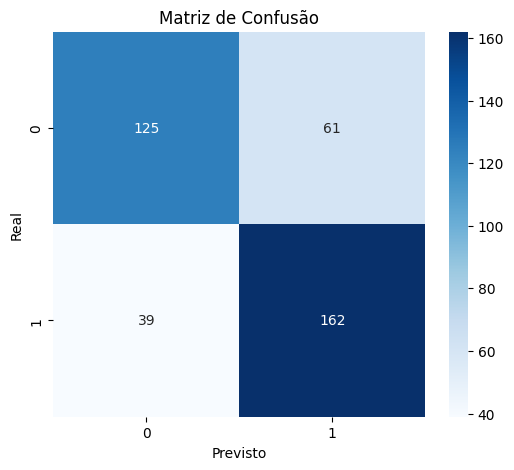

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# Resultado do Modelo Preditivo

Modelo utilizado:

Random Forest Classifier

## Desempenho

Accuracy: 74,16%

## Classe de Risco

Precision: 73%

Recall: 81%

F1-Score: 76%

## Insight Executivo

O modelo foi capaz de identificar 81% dos estudantes que efetivamente apresentaram risco futuro de defasagem.

Os resultados demonstram potencial para utilização como ferramenta de alerta precoce, permitindo que a Passos Mágicos priorize intervenções junto aos estudantes com maior probabilidade de apresentar dificuldades futuras.

In [ ]:
importances = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo.feature_importances_
})

importances = (
    importances
    .sort_values(
        'Importancia',
        ascending=False
    )
)

importances

,Variavel,Importancia
4,IPV,0.224743
3,IDA,0.150595
1,IEG,0.134893
7,Idade 22,0.113238
2,IPS,0.111299
0,IAA,0.102370
6,Ano ingresso,0.083272
5,IAN,0.079590


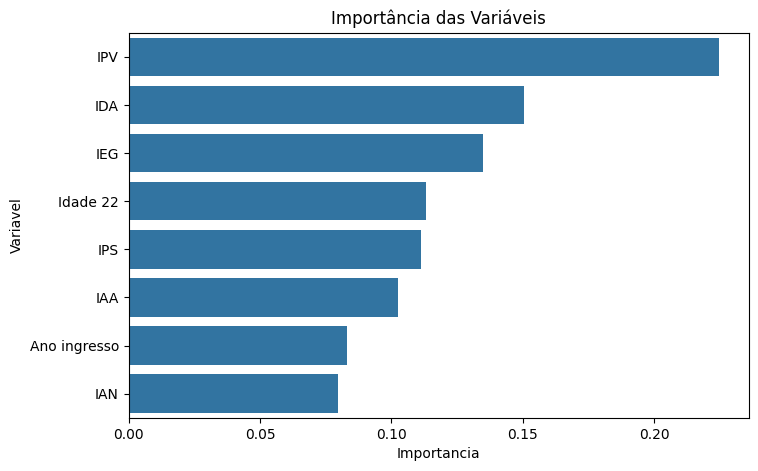

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importances,
    x='Importancia',
    y='Variavel'
)

plt.title('Importância das Variáveis')

plt.show()

# Resultado do Modelo Preditivo

Modelo: Random Forest

## Desempenho

Accuracy: 74,16%

Recall (classe de risco): 81%

Precision (classe de risco): 73%

F1-Score: 76%

## Principais Variáveis

1. IPV
2. IDA
3. IEG
4. Idade
5. IPS

## Insight Executivo

O modelo foi capaz de identificar 81% dos estudantes que efetivamente apresentaram risco futuro de defasagem.

O Indicador de Ponto de Virada (IPV) foi o principal fator preditivo, seguido pelos indicadores de Aprendizagem (IDA) e Engajamento (IEG).

Os resultados sugerem que ações focadas no fortalecimento do desenvolvimento educacional, da aprendizagem e do engajamento podem contribuir para reduzir o risco futuro de defasagem.